In [5]:
# Librerias a usar
from funciones import *

#import pandas as pd
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt


#Definimos un máximo de hilos a usar
os.environ["OMP_NUM_THREADS"] = "2" 
cv2.setNumThreads(2) 

# Se realiza la carga de las imágenes y se guardan en un dataframe

In [6]:
ruta_imagenes = "../img/Training"
clases = ['normal', 'grieta', 'hueco']

df = load_images(img_directorio_path=ruta_imagenes, classes=clases)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4445 entries, 0 to 4444
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   imagen color  4445 non-null   object
 1   imagen gris   4445 non-null   object
 2   clase         4445 non-null   object
dtypes: object(3)
memory usage: 104.3+ KB


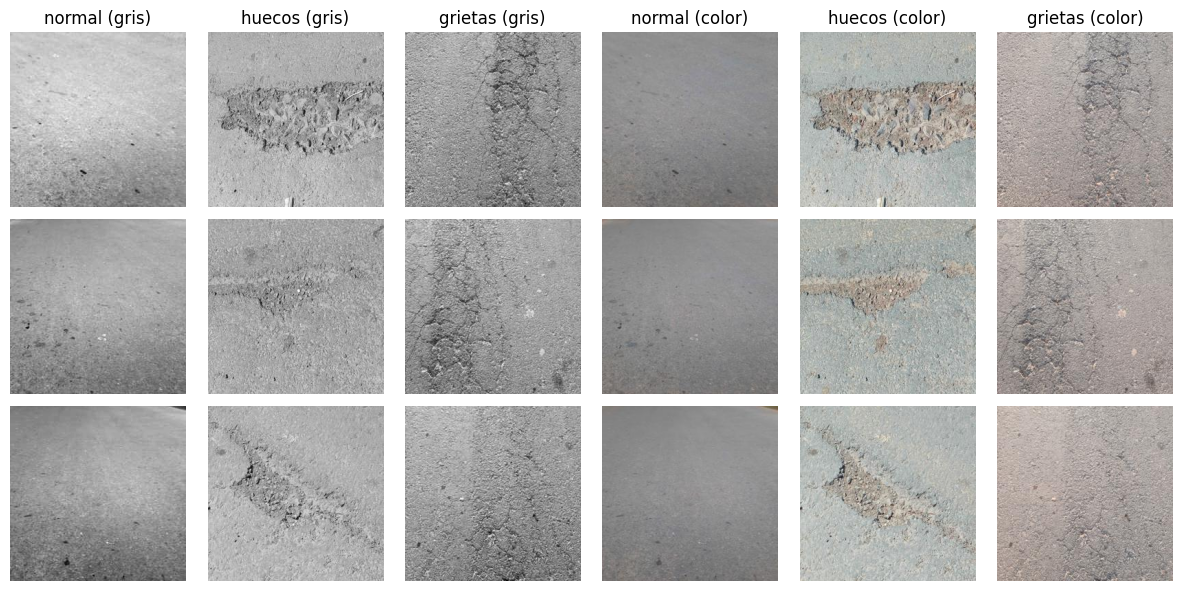

In [8]:
# Graficamos algunas de las imagenes
inicio = 200
final = inicio + 3
graficar = [
    df[df['clase']=='normal']['imagen gris'][inicio:final].tolist(),
    df[df['clase']=='hueco']['imagen gris'][inicio:final].tolist(),
    df[df['clase']=='grieta']['imagen gris'][inicio:final].tolist(),
    df[df['clase']=='normal']['imagen color'][inicio:final].tolist(),
    df[df['clase']=='hueco']['imagen color'][inicio:final].tolist(),
    df[df['clase']=='grieta']['imagen color'][inicio:final].tolist()
]

show_images(graficar, ['normal (gris)', 'huecos (gris)', 'grietas (gris)', 'normal (color)', 'huecos (color)', 'grietas (color)'], gray=True)

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['clase'] = le.fit_transform(df['clase'])

In [10]:
import random

# Generar semilla aleatoria
seed = random.randint(0, 10000)
print(f"Semilla usada para el shuffle: {seed}")

# Aplicar shuffle
df_shuffled = df.sample(frac=1, random_state=seed).reset_index(drop=True)

Semilla usada para el shuffle: 5397


In [12]:
#pipeline
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

pipeline = Pipeline([
    ('preproc', ImagePreprocessor()),
    ('bovw', BagOfVisualWords()),   # usa SIFT por defecto
    ('clf', XGBClassifier(eval_metric='mlogloss'))
])


""" param_grid = {
    'preproc__brightness': [0.8, 1.0, 1.2],
    'preproc__contrast': [0.8, 1.0, 1.2],
    'preproc__blur': [(0,0), (3,0), (5,0), (0,2), (3,1), (5,1)],
    'preproc__sobel': [0, 3, 5, 7],
    'preproc__canny': [(0,0), (50,150), (100,300)],
    'preproc__otsu': [False, True],
    'preproc__laplacian': [0,3,5,7],

    'bovw__n_clusters': [2 + i for i in range(20)],
    'bovw__feature_detector': ['SIFT', 'ORB'],
    'bovw__max_descriptors': [100,200,500,1000,2000],
    
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [3, 6],
    'clf__learning_rate': [0.1, 0.3]
} """

param_grid = {
    'preproc__brightness': [1.0],
    'preproc__contrast': [1.0],
    'preproc__blur': [(3, 0)],  # sin blur y un blur ligero
    'preproc__sobel': [0, 3],
    'preproc__canny': [(100, 300)],
    'preproc__otsu': [False],
    'preproc__laplacian': [0],

    'bovw__n_clusters': [10, 20],
    'bovw__feature_detector': ['SIFT'],
    'bovw__max_descriptors': [200],

    'clf__n_estimators': [50],
    'clf__max_depth': [3],
    'clf__learning_rate': [0.1]
}




In [13]:
import sklearn 
import xgboost 
 
print(f"scikit-learn version: {sklearn.__version__}") 
print(f"XGBoost version: {xgboost.__version__}") 

scikit-learn version: 1.6.1
XGBoost version: 3.0.0


In [14]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(pipeline, 
                    param_grid,
                    scoring='f1_weighted',
                    cv=3, 
                    verbose=2,
                    n_jobs = 3)


from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Paso opcional pero recomendado: separar un conjunto de prueba
X_train, X_test, y_train, y_test = train_test_split(
    df_shuffled['imagen gris'], df_shuffled['clase'], test_size=0.4, random_state=42
)

# Ajustar sobre el conjunto de entrenamiento
grid.fit(X_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preproc', ImagePreprocessor()),
                                       ('bovw', BagOfVisualWords()),
                                       ('clf',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric='mlogloss',
                                                      feature_types=None,
                                                      feature_...
             param_grid={'bovw__feature_detector': ['SIFT'],
                         'bovw__max_descriptors': [200],
                         'bovw__n_clusters': [10, 20],
                         'clf__learning_rate': [0.1], 'clf__max_depth': [3],
                         'clf__n_estimators': [50], 'preproc__blur': [(3, 0)],
                         'preproc__brightness': [1.0],
                         'preproc__canny': [(100, 300)],
                         'preproc__contrast': [1.0], 'preproc__laplacian': [0],
                         'preproc__otsu': [False], 'preproc__sobel': [0, 3]},
             scoring='f1_weighted', verbose=2)

In [15]:
import joblib

# Guardar el mejor modelo encontrado
joblib.dump(grid.best_estimator_, 'mejor_modelo')


['mejor_modelo']

In [16]:
import joblib

# Cargar el modelo guardado
modelo_cargado = joblib.load('mejor_modelo')

In [17]:
print("Mejores parámetros encontrados:")
print(grid.best_params_)
print()
# Predicción con el mejor modelo
y_pred = modelo_cargado.predict(X_test)

# Reporte de clasificación
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


# Matriz de confusion
from sklearn.metrics import confusion_matrix
print("Matriz de confusión")
print(confusion_matrix(y_test, y_pred))

Mejores parámetros encontrados:
{'bovw__feature_detector': 'SIFT', 'bovw__max_descriptors': 200, 'bovw__n_clusters': 20, 'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 50, 'preproc__blur': (3, 0), 'preproc__brightness': 1.0, 'preproc__canny': (100, 300), 'preproc__contrast': 1.0, 'preproc__laplacian': 0, 'preproc__otsu': False, 'preproc__sobel': 3}

Reporte de clasificación:
              precision    recall  f1-score   support

      grieta       0.73      0.65      0.69       567
       hueco       0.73      0.75      0.74       619
      normal       0.84      0.91      0.87       592

    accuracy                           0.77      1778
   macro avg       0.77      0.77      0.77      1778
weighted avg       0.77      0.77      0.77      1778

Matriz de confusión
[[369 144  54]
 [106 464  49]
 [ 28  28 536]]
